### Notebook for making additional plots used in the report

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from methods.data_utils import load_data, pre_avg, \
    compute_returns, filter_day, summarize_data

from methods.plotting import set_style
set_style()  # defaults


In [2]:
market = "EURUSD"
df_init = load_data(market=market)
print(len(df_init))
df_init.head()

1330124


,bid,ask,volume,mid_price
datetime,,,,
2026-02-01 22:00:00.410000+00:00,1.18492,1.18547,0,1.185195
2026-02-01 22:00:01.866000+00:00,1.18497,1.18543,0,1.185200
2026-02-01 22:00:06.535000+00:00,1.18499,1.18544,0,1.185215
2026-02-01 22:00:10.246000+00:00,1.18499,1.18539,0,1.185190
2026-02-01 22:00:48.466000+00:00,1.18499,1.18537,0,1.185180


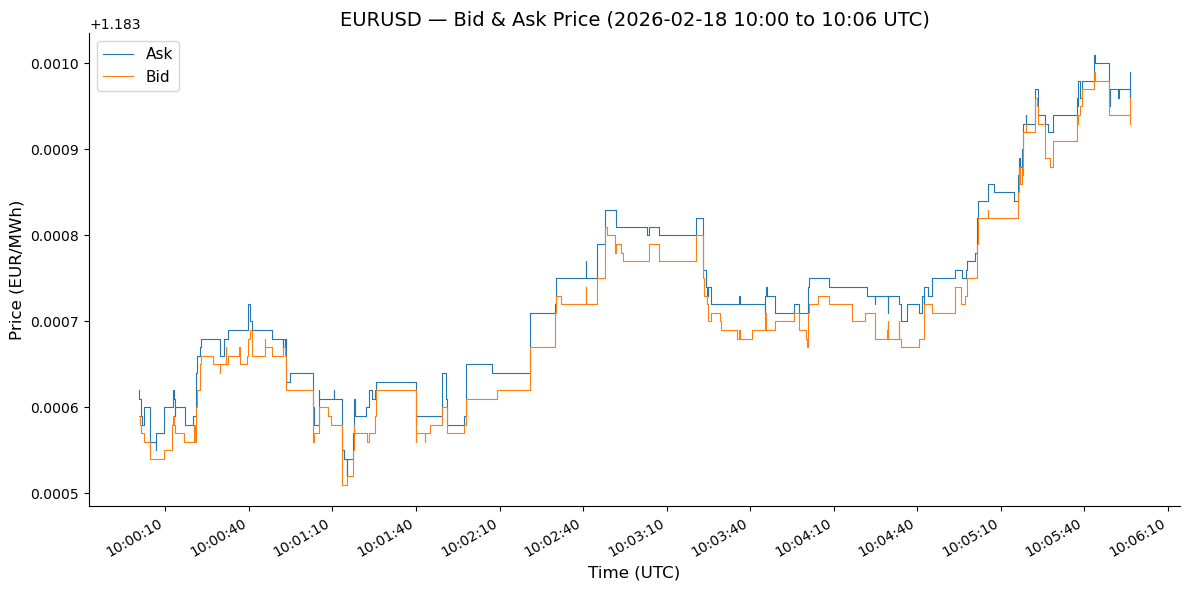

In [23]:
# --- Plot bid and ask price over a 5-hour window ---

# Select a specific trading day, starting at 10:00 UTC
date = pd.Timestamp("2026-02-18")
start = pd.Timestamp(f"{date.date()} 10:00:00", tz="UTC")
end = start + pd.Timedelta(hours=0.1)
df_slice = df_init.loc[start:end]

fig, ax = plt.subplots(figsize=(12, 6))

ax.step(df_slice.index, df_slice["ask"], label="Ask", linewidth=0.8, where="post")
ax.step(df_slice.index, df_slice["bid"], label="Bid", linewidth=0.8, where="post")

# Time axis formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
ax.xaxis.set_major_locator(mdates.SecondLocator(interval=30))
fig.autofmt_xdate(rotation=30)

ax.set_title(f"{market} — Bid & Ask Price ({start.strftime('%Y-%m-%d %H:%M')} to {end.strftime('%H:%M')} UTC)")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Price (EUR/MWh)")
ax.legend()
fig.tight_layout()

plt.savefig(f"../plots/bid_ask{market}.pdf", bbox_inches="tight", format="pdf")
plt.show()
